In [115]:
import pandas as pd
import numpy as np
import scipy as sci
import matplotlib.pyplot as plt
import time

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.data import Data
from torch_geometric.nn import MessagePassing

from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components   

In [117]:
min_size = 100
validation_name = 28

In [118]:
col_names = ['Iso', 'Name', 'E', 'e_E', "v'", "J'", "v''", "J''", 'Tag']
mrt_colspecs = [(0, 6), (7, 9), (10, 25), (26, 34), (35, 37), (38, 41), (42, 44), (45, 48), (49, 65)]
transitions = pd.read_fwf(
    'apjsae40f0t8_mrt.txt', 
    skiprows=19, 
    names=col_names, 
    colspecs=mrt_colspecs,
    header=None
)



marvel_cols = ['Iso', 'Name', 'v', 'J', 'E_marvel', 'e_E_marvel', 'N']
mre_colspecs = [(0, 6), (7, 9), (10, 12), (13, 15), (16, 31), (32, 43), (44, 46)]
marvel_ref = pd.read_fwf(
    'marvel_output.txt', 
    skiprows=18, 
    names=marvel_cols, 
    colspecs=mre_colspecs,
    header=None
)



In [119]:
def create_graph(transitions, energies, exclude_molecules = None,isolate_molecules = None, device = 'cuda'):

    if exclude_molecules is not None:
        energies = energies[energies['Name'] != exclude_molecules].reset_index(drop=True)
        transitions = transitions[transitions['Name'] != exclude_molecules].reset_index(drop=True)

    elif isolate_molecules is not None:
        energies = energies[energies['Name'] == isolate_molecules].reset_index(drop=True)
        transitions = transitions[transitions['Name'] == isolate_molecules].reset_index(drop=True)

    concat = pd.concat([
    transitions[["Name","v'", "J'"]].rename(columns={"v'": "v", "J'": "J"}),
    transitions[["Name","v''", "J''"]].rename(columns={"v''": "v", "J''": "J"})
    ])

    states = concat.drop_duplicates().reset_index(drop=True)
    state_to_idx = dict(zip(zip(states['Name'],states['v'], states['J']), states.index)) 
    idx_to_state = dict(zip(states.index, zip(states['Name'],states['v'], states['J'])))

    ground_state_df = states[(states['v'] == 0) & (states['J'] == 0)]
    if not ground_state_df.empty:
        idx_0_0 = ground_state_df.index[0]
    else:
        idx_0_0 = 0

    source_nodes = []
    for _, row in transitions.iterrows():
        state_key = (row['Name'], row["v''"], row["J''"])
    
        node_idx = state_to_idx[state_key]
        source_nodes.append(node_idx)

    destination_nodes = []
    for _, row in transitions.iterrows():
        state_key = (row['Name'], row["v'"], row["J'"])

        node_idx = state_to_idx[state_key]
        destination_nodes.append(node_idx)

    edge_index_list = [
        source_nodes + destination_nodes,
        destination_nodes + source_nodes]

    edge_index = torch.tensor(edge_index_list, dtype=torch.int64)

    energies_tensor = torch.tensor(transitions[['E', 'e_E']].values, dtype=torch.float)
    
    forward_attr = energies_tensor.clone()
    reverse_attr = energies_tensor.clone()
    reverse_attr[:, 0] = -reverse_attr[:, 0] 
    
    edge_attributes = torch.cat([forward_attr, reverse_attr], dim=0)
    print(energies_tensor)

    x = torch.tensor(states[['v', 'J']].values, dtype= torch.float)


    y_list = np.full((len(states),1), np.nan)

    for _, row in energies.iterrows():
        state_key = (row['Name'], row['v'], row['J'])
    
        if state_key in state_to_idx:
            idx = state_to_idx[state_key]
            y_list[idx] = row['E_marvel']   


    y = torch.tensor(y_list, dtype=torch.float)
    train_mask = ~torch.isnan(y).squeeze()

    gnn_data = Data(
        x=x,                  
        edge_index=edge_index, 
        edge_attr=edge_attributes,  
        y=y,                  
        train_mask=train_mask,
        idx_0_0=torch.tensor([idx_0_0], dtype=torch.long) 
    ).to(device)

    return gnn_data, state_to_idx, idx_to_state

    

In [120]:
train_data, _, _ =  create_graph(transitions, marvel_ref, exclude_molecules=validation_name)
test_data, test_state_to_idx, test_idx_to_state = create_graph(transitions, marvel_ref, isolate_molecules= validation_name)

tensor([[3.7479e+00, 1.6700e-06],
        [7.4957e+00, 2.6700e-06],
        [1.1243e+01, 1.3300e-07],
        ...,
        [1.8177e+03, 2.7100e-03],
        [1.8201e+03, 2.7100e-03],
        [1.8295e+03, 2.7100e-03]])
tensor([[3.2941e+01, 4.0000e-05],
        [3.6597e+01, 4.0000e-05],
        [4.0252e+01, 4.0000e-05],
        ...,
        [2.1257e+03, 2.6250e-03],
        [2.1321e+03, 2.6250e-03],
        [2.1587e+03, 2.6250e-03]])


In [121]:
class SpectroConv(MessagePassing):
    def __init__(self, hidden_dim):
        super(SpectroConv, self).__init__(aggr='mean')

        self.msg_mlp = nn.Sequential(
            nn.Linear(2 * hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )

        self.energy_proj = nn.Linear(1, hidden_dim)

        self.update_mlp = nn.Sequential(
            nn.Linear(2 * hidden_dim, hidden_dim),
        )

    def forward(self, x, edge_index, edge_attr):
        return self.propagate(edge_index, x=x, edge_attr=edge_attr)

    def message(self, x_i, x_j, edge_attr):
        trans_E = edge_attr[:, 0:1] 

        state_interaction = self.msg_mlp(torch.cat([x_i, x_j], dim=-1))

        energy_shift = self.energy_proj(trans_E)

        return state_interaction + energy_shift

    def update(self, aggr_out, x):
        new_state = torch.cat([x, aggr_out], dim=-1)
        return self.update_mlp(new_state) + x

In [122]:
class EnergyGNN(nn.Module):
    def __init__(self, num_layers=3, hidden_dim=64):
        super().__init__()

        self.node_embed = nn.Sequential(
            nn.Linear(2, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )

        self.convs = nn.ModuleList([
            SpectroConv(hidden_dim) for _ in range(num_layers)
        ])

        self.readout = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, 1)
        )

    def forward(self, x, edge_index, edge_attr):
        
        h = self.node_embed(x)
        for conv in self.convs:
            h = conv(h, edge_index, edge_attr)
            
        out = self.readout(h)
        return out   

In [123]:
def train_gnn(train_data, test_data, epochs=1000, lr=0.001, lambda_edge=0.5):
    model = EnergyGNN(num_layers=3, hidden_dim=64).to('cuda')
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.HuberLoss()
    
    train_history = []
    test_history = []
    
    for epoch in range(1, epochs + 1):
        model.train()
        optimizer.zero_grad()
        
        pred_y = model(train_data.x, train_data.edge_index, train_data.edge_attr)
        pred_y = pred_y - pred_y[train_data.idx_0_0]
        
        node_loss = loss_fn(pred_y[train_data.train_mask], train_data.y[train_data.train_mask])
        
        src_preds = pred_y[train_data.edge_index[0]]
        dst_preds = pred_y[train_data.edge_index[1]]
        

        pred_transitions = dst_preds - src_preds
        edge_loss = loss_fn(pred_transitions, train_data.edge_attr[:, 0:1])
        
        total_loss = node_loss + (lambda_edge * edge_loss)
        
        total_loss.backward()
        optimizer.step()
        
        model.eval()
        with torch.no_grad():
            test_pred = model(test_data.x, test_data.edge_index, test_data.edge_attr)
            test_pred = test_pred - test_pred[test_data.idx_0_0]
            
            test_node_loss = loss_fn(test_pred[test_data.train_mask], test_data.y[test_data.train_mask])
            
            test_src = test_pred[test_data.edge_index[0]]
            test_dst = test_pred[test_data.edge_index[1]]
            
            test_transitions = test_dst - test_src
            test_edge_loss = loss_fn(test_transitions, test_data.edge_attr[:, 0:1])
            
            test_total_loss = test_node_loss + (lambda_edge * test_edge_loss)
            
        train_history.append(total_loss.item())
        test_history.append(test_total_loss.item())
        
        if epoch % 100 == 0:
            print(f"Epoch {epoch:04d} | Train Loss: {total_loss.item():.4f} | Test Loss: {test_total_loss.item():.4f}")
            
    return model, train_history, test_history

Epoch 0100 | Train Loss: 1009.7708 | Test Loss: 821.7374
Epoch 0200 | Train Loss: 677.6027 | Test Loss: 825.5601
Epoch 0300 | Train Loss: 630.7180 | Test Loss: 819.2166
Epoch 0400 | Train Loss: 756.2541 | Test Loss: 468.5163
Epoch 0500 | Train Loss: 573.2507 | Test Loss: 608.0559
Epoch 0600 | Train Loss: 624.1120 | Test Loss: 721.4439
Epoch 0700 | Train Loss: 518.0990 | Test Loss: 472.7881
Epoch 0800 | Train Loss: 681.0334 | Test Loss: 353.6753
Epoch 0900 | Train Loss: 487.6837 | Test Loss: 486.7010
Epoch 1000 | Train Loss: 524.6864 | Test Loss: 593.1912


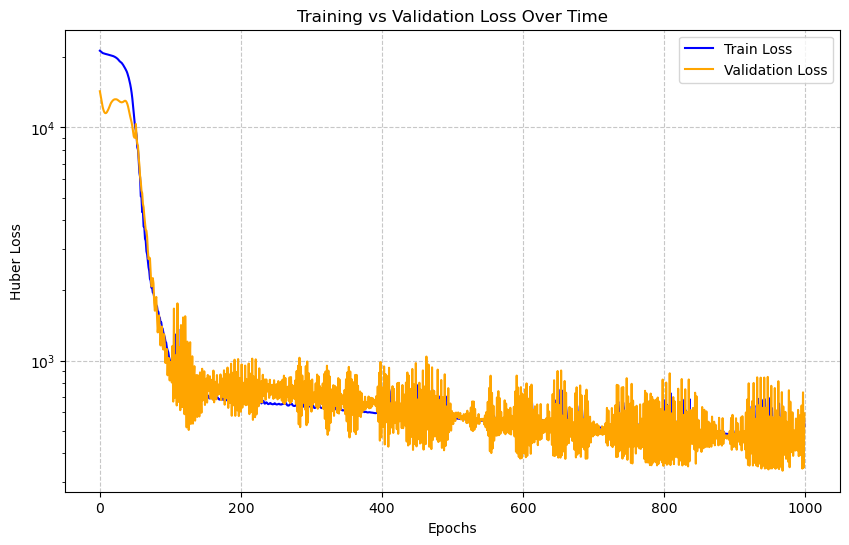

In [124]:

model, train_history, test_history = train_gnn(train_data, test_data)


plt.figure(figsize=(10, 6))
plt.plot(train_history, label='Train Loss', color='blue')
plt.plot(test_history, label='Validation Loss', color='orange')


plt.xlabel('Epochs')
plt.ylabel('Huber Loss')
plt.yscale('log')
plt.title('Training vs Validation Loss Over Time')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

In [125]:


model.eval()

with torch.no_grad():
    test_preds = model(test_data.x, test_data.edge_index, test_data.edge_attr)
    test_preds = test_preds - test_preds[test_data.idx_0_0]

preds = test_preds.detach().cpu().numpy().squeeze()
ground_truth = test_data.y.detach().cpu().numpy().squeeze()
v_numbers = test_data.x[:, 0].detach().cpu().numpy()
j_numbers = test_data.x[:, 1].detach().cpu().numpy()

num_nodes = len(preds)
edges = test_data.edge_index.cpu().numpy()
adj = csr_matrix((np.ones(edges.shape[1]), (edges[0], edges[1])), shape=(num_nodes, num_nodes))
_, comp_labels = connected_components(adj, directed=False)


results_df = pd.DataFrame({
    'Node_Idx': np.arange(len(preds)),
    'Molecule_Name': validation_name,
    'Component': comp_labels + 1,
    'v': v_numbers.astype(int),
    'J': j_numbers.astype(int),
    'Energy': preds,
    'E_Ground_Truth': ground_truth,
    'Residual': preds - ground_truth,
})

results_df_sorted = results_df.sort_values(by=['Component', 'v', 'J']).reset_index(drop=True)

matched_df = results_df_sorted.dropna(subset=['Residual']).copy()

results_df_sorted.to_csv('gnn_marvel_energy_predictions_sorted.csv', index=False)

for comp_id, comp_group in results_df_sorted.groupby('Component'):
    comp_matched = comp_group.dropna(subset=['Residual'])
    n_matched = len(comp_matched)
    
    if n_matched > 0:
        res = comp_matched['Residual'].values
        rmse = np.sqrt(np.mean(res**2))
        mae = np.mean(np.abs(res))
        max_err = np.max(np.abs(res))
        
        print(f"\nComponent {comp_id}:")
        print(f" Calculated: {len(comp_group)}")
        print(f" Matched: {n_matched}")
        print(f" RMS: {rmse:.6e} ")
        print(f" MAE: {mae:.6e} ")
        print(f" Max Residal: {max_err:.6e}\n")
    else:
        print(f"Floating Component {comp_id}: {len(comp_group)} levels")


Component 1:
 Calculated: 498
 Matched: 498
 RMS: 6.181255e+02 
 MAE: 4.980742e+02 
 Max Residal: 3.131115e+03

Floating Component 2: 9 levels
Floating Component 3: 8 levels
Floating Component 4: 12 levels
Floating Component 5: 2 levels
Floating Component 6: 4 levels
Floating Component 7: 2 levels
Floating Component 8: 5 levels
Floating Component 9: 7 levels
Floating Component 10: 9 levels
Floating Component 11: 2 levels
Floating Component 12: 2 levels
Floating Component 13: 2 levels
Floating Component 14: 2 levels
Floating Component 15: 2 levels
Floating Component 16: 2 levels
Floating Component 17: 5 levels
Floating Component 18: 2 levels
Floating Component 19: 2 levels
Floating Component 20: 4 levels
Floating Component 21: 6 levels
Floating Component 22: 2 levels
Floating Component 23: 2 levels
Floating Component 24: 4 levels
Floating Component 25: 2 levels
Floating Component 26: 2 levels
Floating Component 27: 2 levels
Floating Component 28: 2 levels
Floating Component 29: 2 level

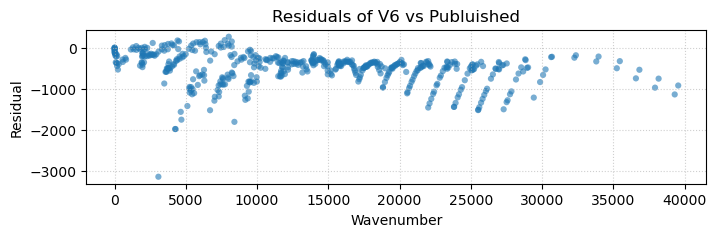

In [126]:
plt.figure(figsize=(8, 2))
plt.scatter(matched_df['Energy'], matched_df['Residual'], alpha=0.6, edgecolors='none', s=20)
plt.xlabel('Wavenumber')
plt.ylabel('Residual')
plt.title(f'Residuals of V6 vs Publuished')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()